# Experiment 5

**Aim:** Apply descriptive statistics, data preprocessing, feature scaling and encoding techniques. Perform feature selection and also build and evaluate a logistic regression model on two datasets (regression and classification)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Dataset 1 : Wine Dataset (Classification)

In [ ]:
import pandas as pd

columns = [
    "Class",
    "Alcohol",
    "Malic_Acid",
    "Ash",
    "Alcalinity_of_Ash",
    "Magnesium",
    "Total_Phenols",
    "Flavanoids",
    "Nonflavanoid_Phenols",
    "Proanthocyanins",
    "Color_Intensity",
    "Hue",
    "OD280_OD315",
    "Proline"
]

df = pd.read_csv("wine.data", header=None, names=columns)

In [ ]:
df.head()

,Class,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


 ### Descriptive Statistical Analysis and Data Preprocessing

In [ ]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Class                 178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic_Acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Alcalinity_of_Ash     178 non-null    float64
 5   Magnesium             178 non-null    int64  
 6   Total_Phenols         178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid_Phenols  178 non-null    float64
 9   Proanthocyanins       178 non-null    float64
 10  Color_Intensity       178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD280_OD315           178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [ ]:
df.describe(percentiles=[0.1,0.25,0.5,0.75,0.9])

,Class,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
10%,1.000000,11.933000,1.247000,2.000000,16.000000,85.000000,1.471000,0.607000,0.217000,0.854000,2.549000,0.610000,1.580000,406.700000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
90%,3.000000,14.100000,3.983000,2.700000,24.000000,118.000000,3.044000,3.233000,0.530000,2.305000,8.530000,1.233000,3.456000,1261.500000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [ ]:
df.columns

Index(['Class', 'Alcohol', 'Malic_Acid', 'Ash', 'Alcalinity_of_Ash',
       'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280_OD315', 'Proline'],
      dtype='object')

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
df.columns

Index(['Class', 'Alcohol', 'Malic_Acid', 'Ash', 'Alcalinity_of_Ash',
       'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280_OD315', 'Proline'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Class,0
Alcohol,0
Malic_Acid,0
Ash,0
Alcalinity_of_Ash,0
Magnesium,0
Total_Phenols,0
Flavanoids,0
Nonflavanoid_Phenols,0
Proanthocyanins,0


In [ ]:
df.duplicated().sum()

np.int64(0)

####Feature scaling
a data preprocessing step where we bring all numerical features to a common scale so that no single feature dominates the model because of its magnitude.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Basic plotting and visualization on the data set

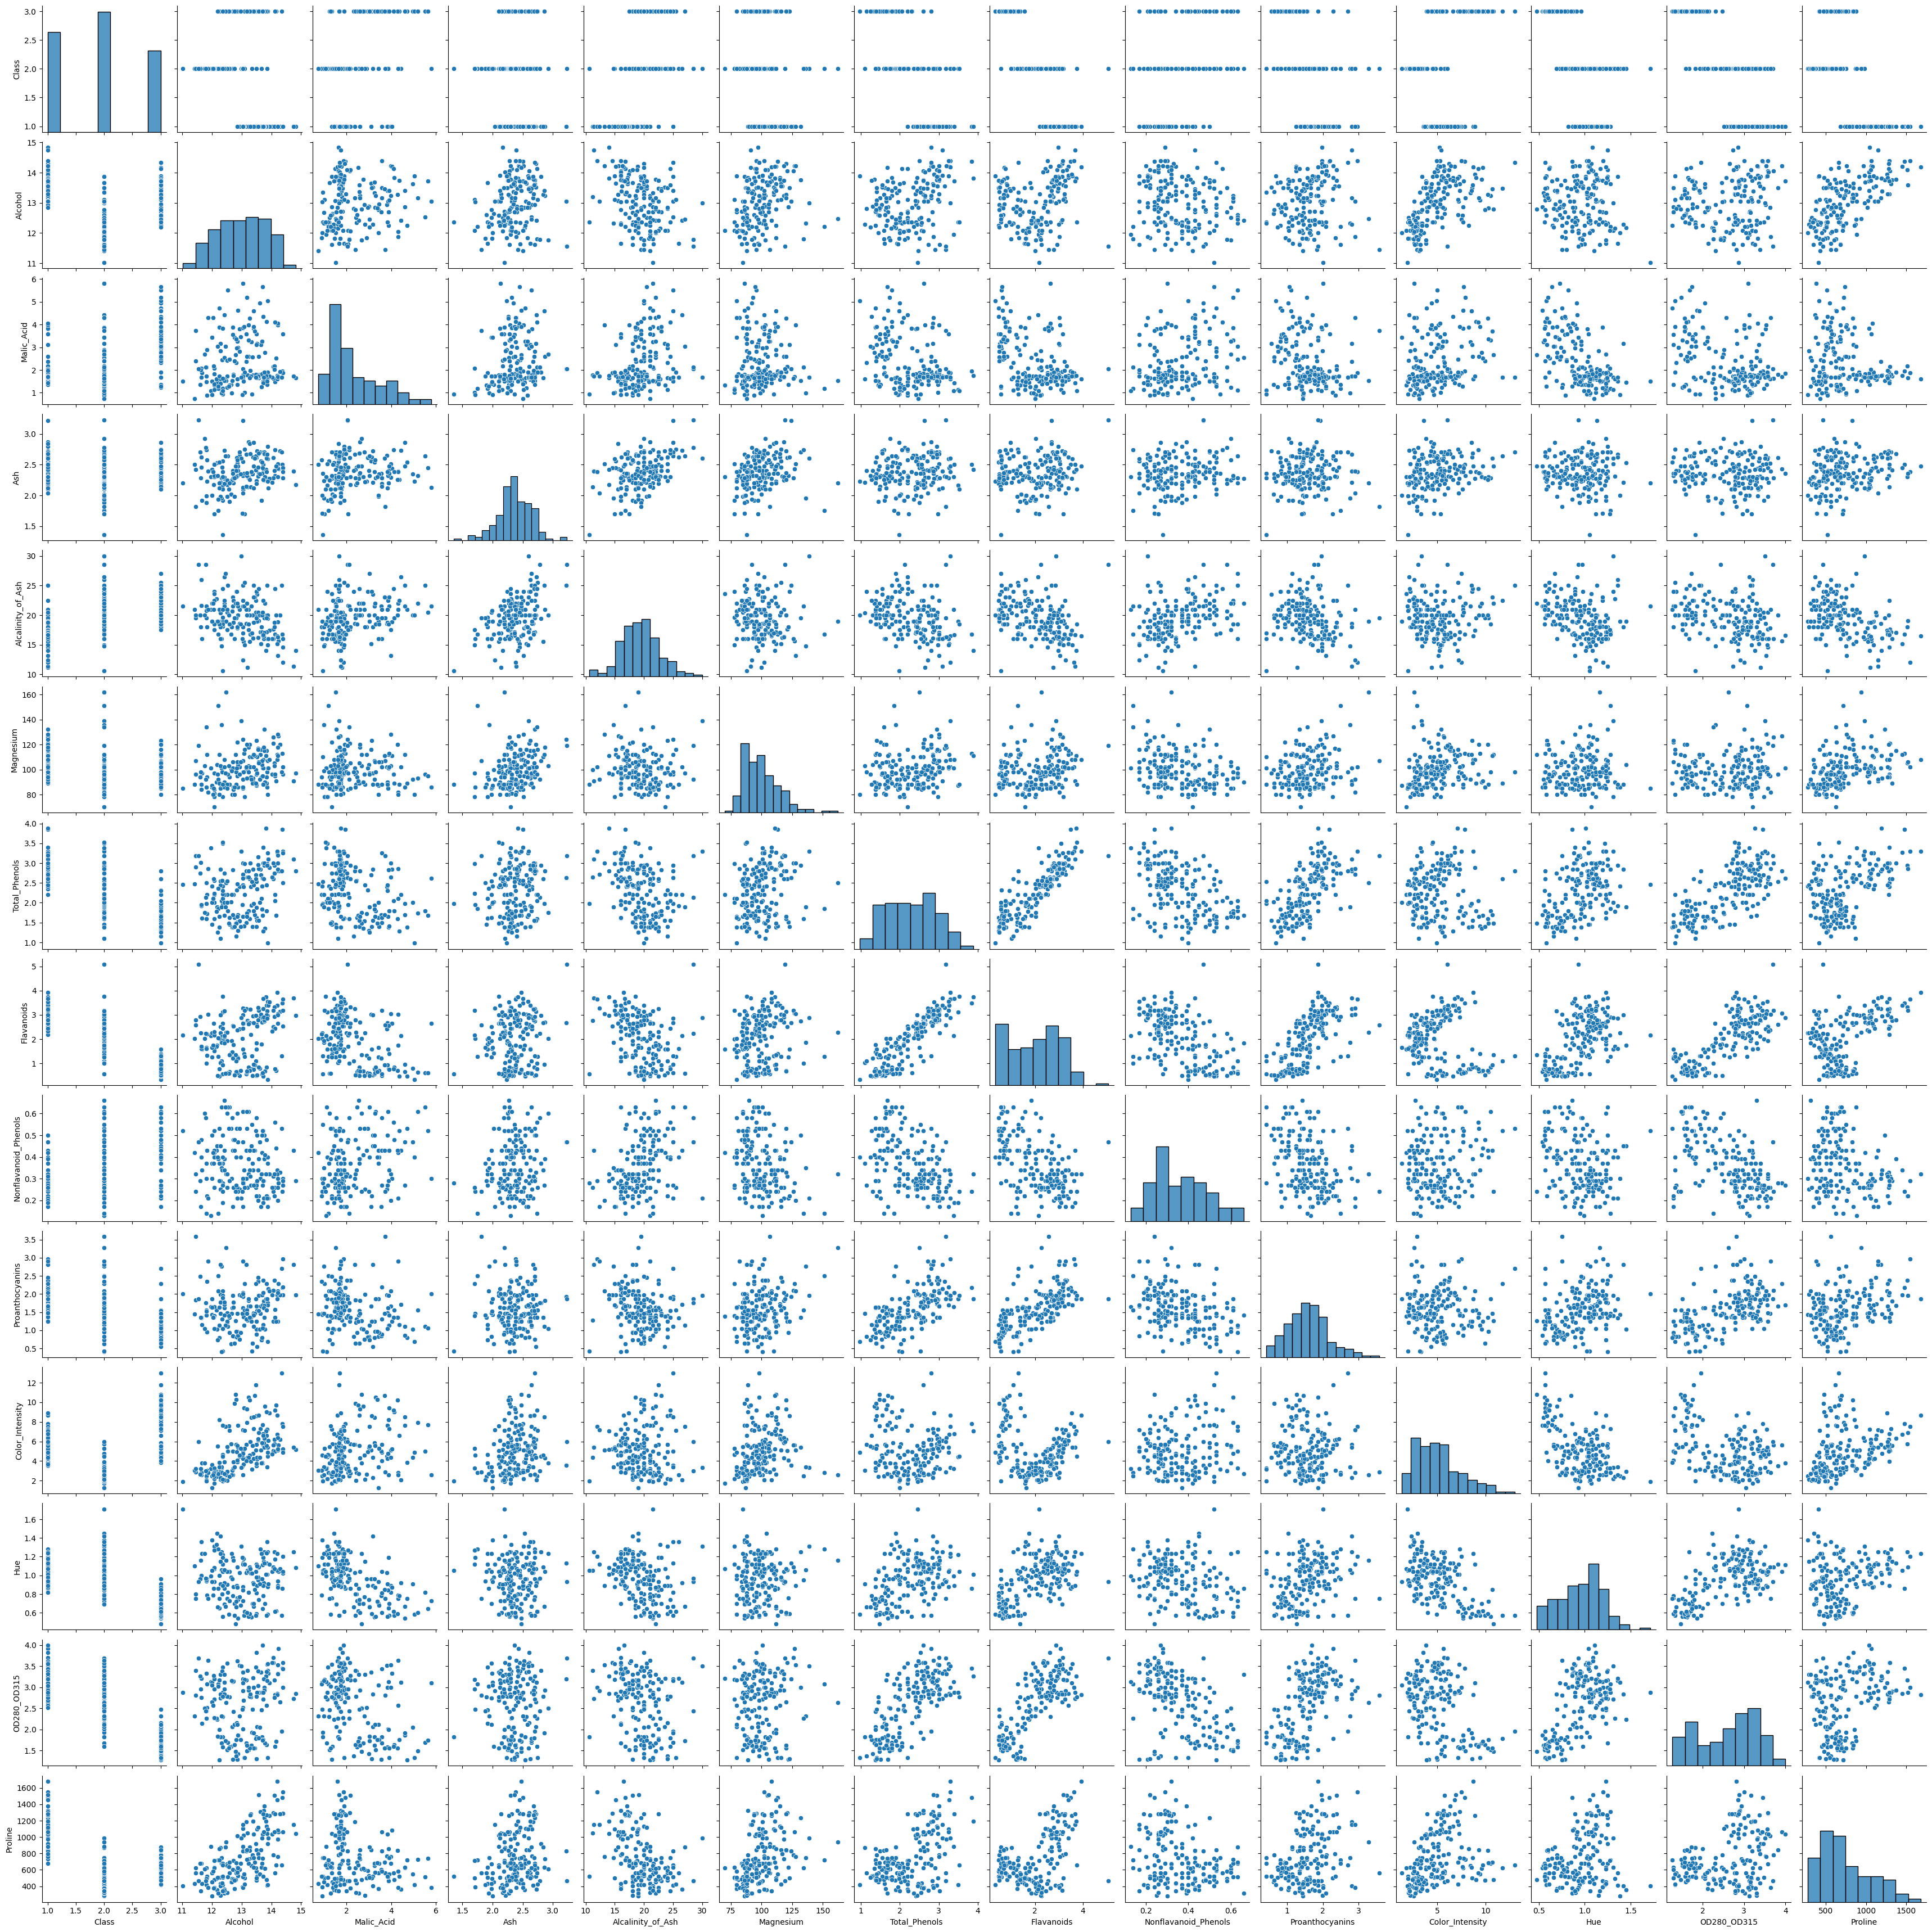

In [ ]:
sns.pairplot(df)

Class Distribution

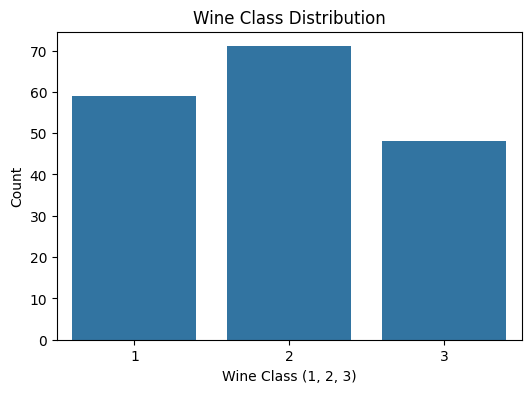

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Wine Class Distribution")
plt.xlabel("Wine Class (1, 2, 3)")
plt.ylabel("Count")
plt.show()

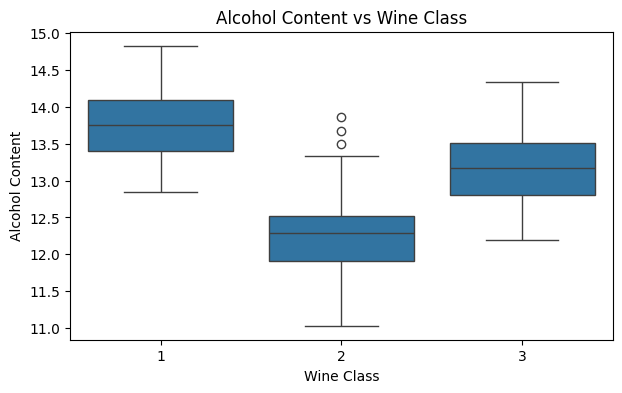

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(x=y, y=df['Alcohol'])
plt.title("Alcohol Content vs Wine Class")
plt.xlabel("Wine Class")
plt.ylabel("Alcohol Content")
plt.show()

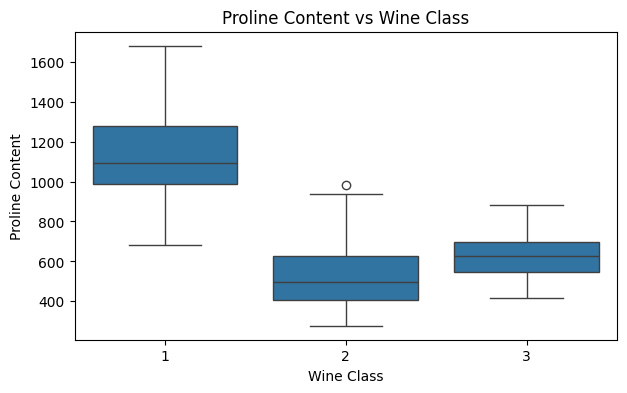

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(x=y, y=df['Proline'])
plt.title("Proline Content vs Wine Class")
plt.xlabel("Wine Class")
plt.ylabel("Proline Content")
plt.show()

<Axes: ylabel='Density'>

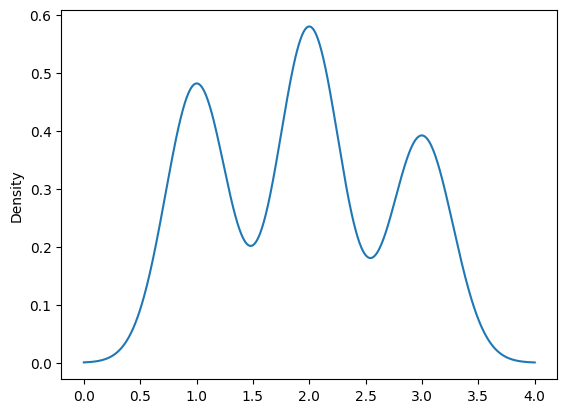

In [ ]:
df['Class'].plot.density()

### Feature Selection
the process of identifying and keeping only the most relevant features for building a machine learning model.

correlation analysis to remove redundant features

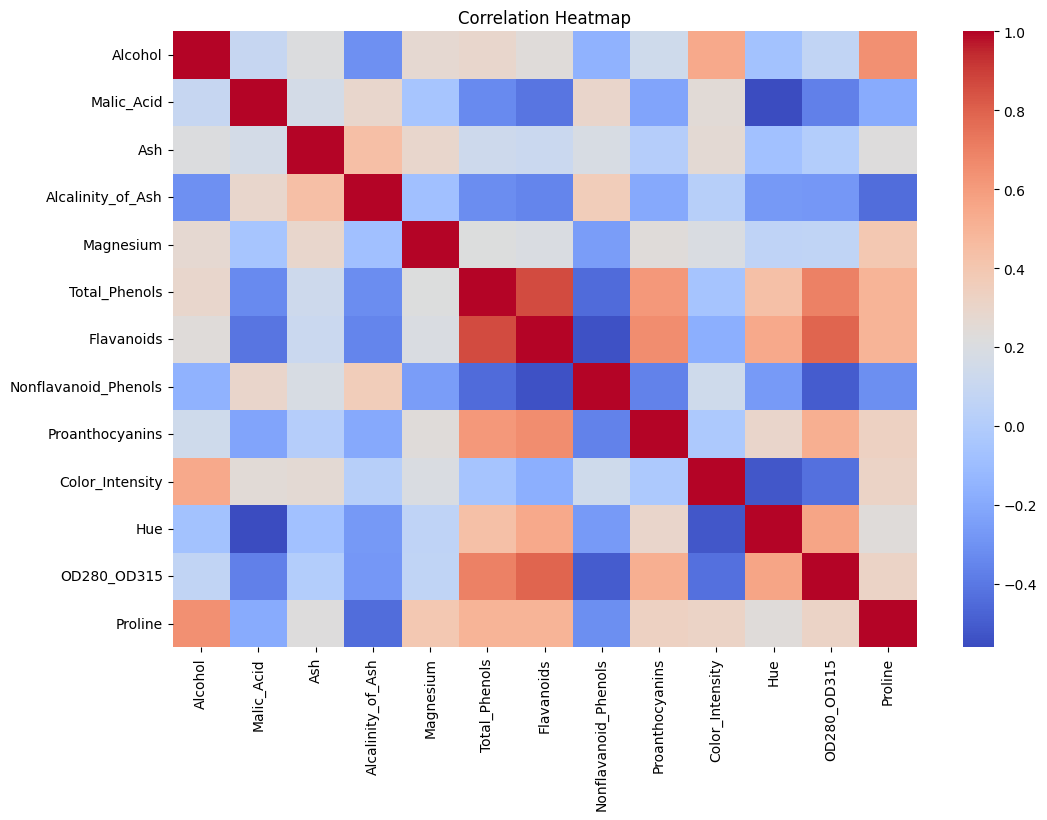

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(pd.DataFrame(X, columns=X.columns).corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Regression coefficients to identify the most influential features contributing to classification

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_temp = LogisticRegression(max_iter=1000, multi_class='ovr')
lr_temp.fit(X_scaled, y)

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": abs(lr_temp.coef_).mean(axis=0)
})

coeff_df.sort_values(by="Coefficient", ascending=False)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,Feature,Coefficient
12,Proline,1.285023
0,Alcohol,1.166753
9,Color_Intensity,1.053379
6,Flavanoids,0.995151
2,Ash,0.916377
3,Alcalinity_of_Ash,0.873341
11,OD280_OD315,0.754250
10,Hue,0.751940
1,Malic_Acid,0.535720
8,Proanthocyanins,0.355240


In [ ]:
features_to_drop = [
    'Magnesium',
    'Nonflavanoid_Phenols',
    'Total_Phenols'
]

X_selected = X.drop(columns=features_to_drop)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_selected_scaled, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, multi_class='ovr')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


0.9722222222222222

### Train–Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected_scaled,  # scaled + feature-selected data
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Logistic Regression Model (Multiclass)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    multi_class='ovr'
)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='ovr')

 Model Prediction

In [ ]:
y_pred = model.predict(X_test)

Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9722222222222222

Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[12,  0,  0],
       [ 0, 14,  0],
       [ 0,  1,  9]])

Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       0.93      1.00      0.97        14
           3       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



## Final Observations

• The dataset is suitable for multiclass classification

• Feature scaling improved model performance

• Feature selection reduced redundancy

• Logistic Regression effectively classified wine samples

• The model generalized well on unseen data


## Dataset 2: US Housing Dataset (Regression)

In [ ]:
import pandas as pd

df = pd.read_csv("USA_Housing.csv")
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [ ]:
df.drop('Address', axis=1, inplace=True)

Convert Regression → Classification

	•	0 → Low-priced house
	•	1 → High-priced house

In [ ]:
median_price = df['Price'].median()

df['Price_Category'] = (df['Price'] > median_price).astype(int)

Seperate Features and Target

In [ ]:
X = df.drop(['Price', 'Price_Category'], axis=1)
y = df['Price_Category']

In [ ]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price',
       'Price_Category'],
      dtype='object')

### Basic plotting and visualization on the data set

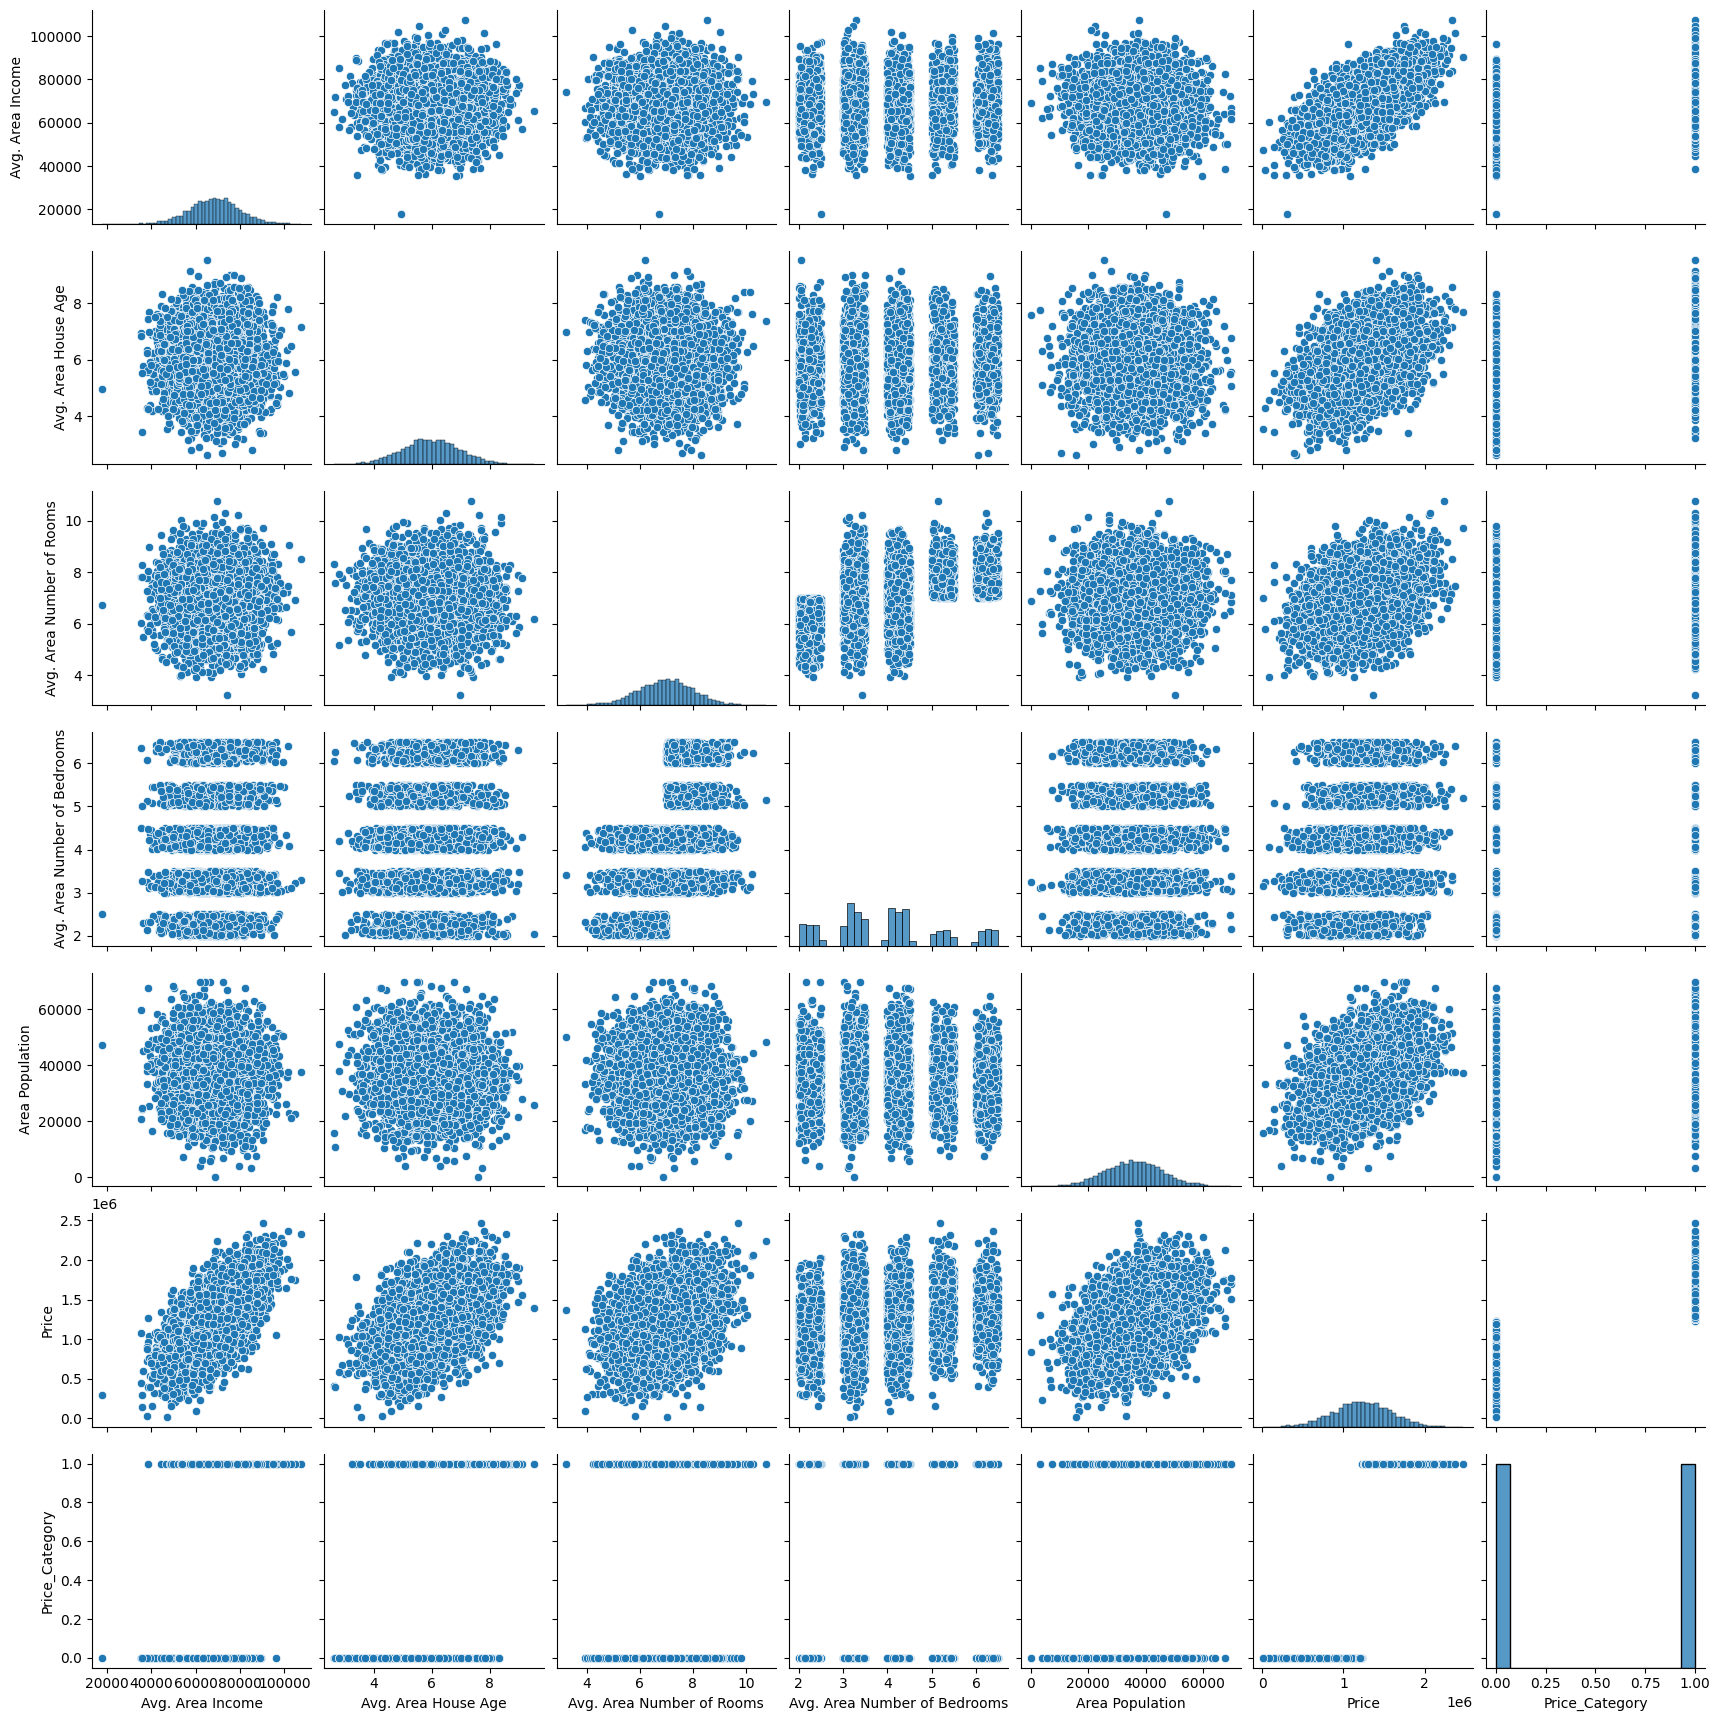

In [ ]:
sns.pairplot(df)

<Axes: ylabel='Frequency'>

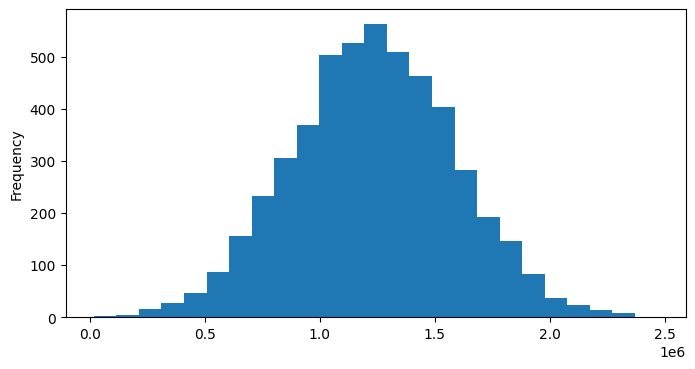

In [ ]:
df['Price'].plot.hist(bins=25,figsize=(8,4))

<Axes: ylabel='Density'>

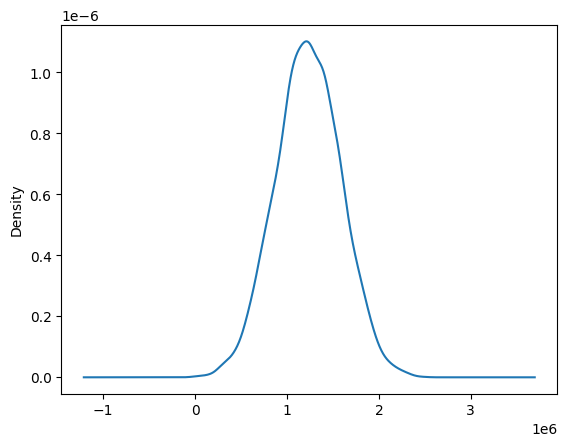

In [ ]:
df['Price'].plot.density()

In [ ]:
df.corr()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Price_Category
Avg. Area Income,1.000000,-0.002007,-0.011032,0.019788,-0.016234,0.639734,0.505830
Avg. Area House Age,-0.002007,1.000000,-0.009428,0.006149,-0.018743,0.452543,0.365473
Avg. Area Number of Rooms,-0.011032,-0.009428,1.000000,0.462695,0.002040,0.335664,0.262797
Avg. Area Number of Bedrooms,0.019788,0.006149,0.462695,1.000000,-0.022168,0.171071,0.130379
Area Population,-0.016234,-0.018743,0.002040,-0.022168,1.000000,0.408556,0.329347
Price,0.639734,0.452543,0.335664,0.171071,0.408556,1.000000,0.799459
Price_Category,0.505830,0.365473,0.262797,0.130379,0.329347,0.799459,1.000000


<Axes: >

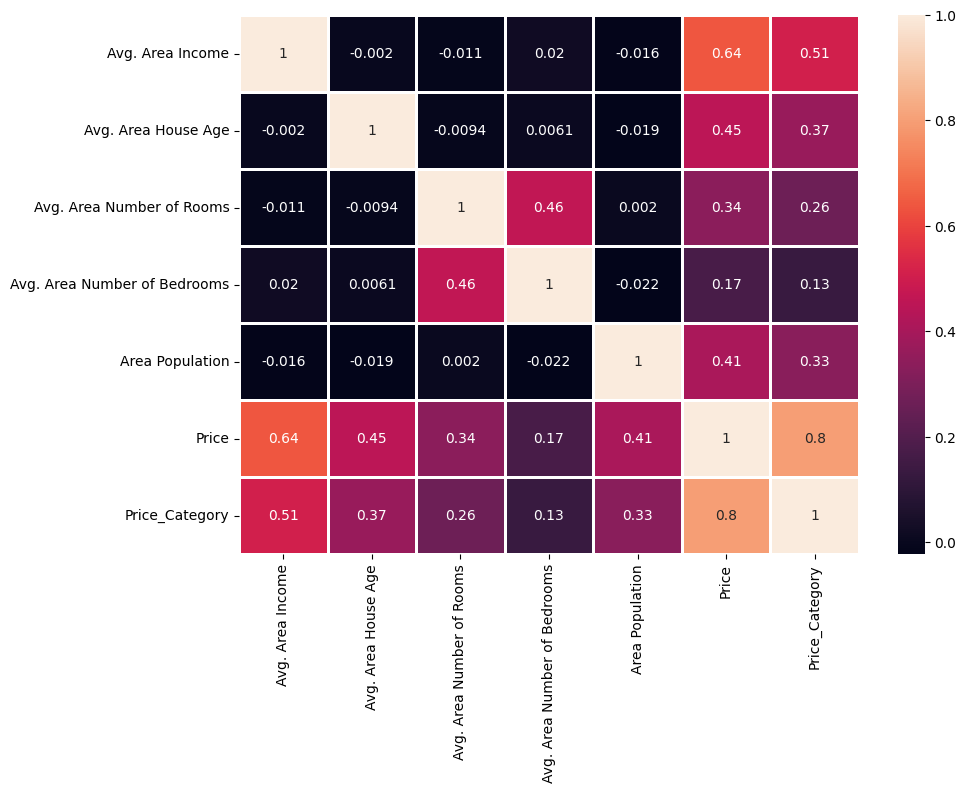

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(),annot=True,linewidths=2)

Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train–Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Train Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.916

Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[449,  51],
       [ 33, 467]])

 Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.90      0.91       500
           1       0.90      0.93      0.92       500

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



### Final Observations

• Converted regression problem into classification

• Applied scaling and preprocessing

• Logistic Regression classified house prices effectively

• Model generalized well on test data